# Long-context retrieval on hosted models (no GPU)

Every model here runs behind an API. Use **Runtime > Change runtime type > CPU**:
nothing is loaded locally, so this notebook uses no T4 time. It covers the
models the local notebook could not load, starting with the three hosted models
the v3 run never reached.

**Free access first.** Add whichever keys you have as Colab secrets (key icon,
left sidebar). Providers without a key are skipped, and each model falls back to
the next provider that serves it.

| Secret | Provider | Allowance (checked 16 Sep 2026) |
| --- | --- | --- |
| `OPENROUTER_API_KEY` | OpenRouter, `:free` models | 20 requests a minute; 50 a day, or 1,000 a day once $10 of credit has ever been bought |
| `GEMINI_API_KEY` | Google AI Studio | free tier for the Flash models and Gemma 4; limits shown in AI Studio |
| `HF_TOKEN` | Hugging Face Inference Providers | a monthly credit, used up in the v3 run (`402`); it resets monthly |

**Which models, and why.** The model list was checked against each provider's
live catalogue, since free models are withdrawn often (every free route in the
first draft of this notebook had been). It covers two groups:

| Model | Architecture (model card) | Route | Thinking |
| --- | --- | --- | --- |
| Gemma 4 31B | dense transformer | OpenRouter, Gemini, HF | off by default |
| Inkling Small | MoE, 276B total / 12B active | OpenRouter | switched off |
| Nemotron 3 Super 120B | hybrid Mamba-Transformer MoE | OpenRouter | cannot be switched off (lowest: `low`) |
| LFM2.5 2.6B | hybrid: 22 short-convolution + 8 attention blocks | OpenRouter | always on |
| Nemotron 3 Ultra 550B | hybrid Transformer-Mamba MoE | OpenRouter | cannot be switched off (lowest: `medium`) |
| Gemini 2.5 Flash-Lite | closed | Gemini | switched off |
| Llama 3.3 70B, Qwen2.5 72B, DeepSeek-V3 | the three v3 never reached | HF (paid credit only) | none |

The hybrids matter for the paper: like the controlled models, most of their
layers are not global attention. They also think before answering, and that
changes the task: a model that reasons can search the context in its own
output rather than retrieve in one pass. The notebook turns thinking off
wherever the provider allows, records it wherever it cannot, and reports the
two groups separately.

At 35 calls per model, OpenRouter's 50-a-day cap covers about one model a day.
Results are appended to a file on Drive and a rerun skips finished cases, so the
list completes over a few days, or in one session after a one-time $10 top-up.

**Probes.** Same seven as the local notebook, with v3's two bugs fixed (`nearkey`
distractors no longer reuse the target key; the `count` answer now varies):

| Probe | The task | Defeats |
| --- | --- | --- |
| `simple` | one fact, question repeats its wording | nothing: ceiling reference |
| `multikey` | 65 competing facts of the same form | single-needle search |
| `nearkey` | competitors differ by one character | fuzzy key matching |
| `paraphrase` | six statement forms, reworded question | template matching |
| `twohop` | the code is reached through a second fact | direct lookup |
| `update` | the fact is stated, then revised later | recency versus retrieval |
| `count` | how many codes start with a digit | not retrieval: a control |

**Wrong answers are classified.** `wrong_fact` is a code that appears in the
context but belongs to another key. `stale_value` is the code before revision in
`update`. `invented` is a code-shaped string that appears nowhere. `no_code` is
prose instead of a code. The controlled study found that several apparent
retrieval failures were really answer-format failures, so the two are reported
separately here too.

In [1]:
!pip -q install openai transformers

import json, os, random, re, time
from collections import Counter, defaultdict
from pathlib import Path

try:                                   # keep results across runtime resets and days
    from google.colab import drive
    drive.mount("/content/drive")
    OUT_DIR = Path("/content/drive/MyDrive/sinkprobe")
except Exception as exc:
    print("Drive not mounted; results stay on this runtime:", exc)
    OUT_DIR = Path(".")
OUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS = OUT_DIR / "hosted_probe_results.jsonl"


def secret(name):
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return os.environ.get(name)


KEYS = {s: secret(s) for s in ("OPENROUTER_API_KEY", "GEMINI_API_KEY", "HF_TOKEN")}
print("keys found:", [k for k, v in KEYS.items() if v] or "none")
assert any(KEYS.values()), "add at least one key as a Colab secret"
print("results file:", RESULTS)

Mounted at /content/drive
keys found: ['HF_TOKEN']
results file: /content/drive/MyDrive/sinkprobe/hosted_probe_results.jsonl


In [2]:
from openai import OpenAI

import urllib.request

# name: (OpenAI-compatible base URL, secret, seconds between calls, call cap per session)
PROVIDERS = {
    "openrouter": ("https://openrouter.ai/api/v1", "OPENROUTER_API_KEY", 3.5, 50),
    "gemini":     ("https://generativelanguage.googleapis.com/v1beta/openai/", "GEMINI_API_KEY", 6.5, 90),
    "hf":         ("https://router.huggingface.co/v1", "HF_TOKEN", 0.5, 120),
}

# In order of value per call. Routes are tried in order; a route that is gone is skipped.
MODELS = {
    "Gemma-4-31B":           [("openrouter", "google/gemma-4-31b-it:free"),
                              ("gemini", "gemma-4-31b-it"),
                              ("hf", "google/gemma-4-31B-it")],
    "Nemotron-3-Super-120B": [("openrouter", "nvidia/nemotron-3-super-120b-a12b:free")],
    "LFM2.5-2.6B":           [("openrouter", "liquid/lfm-2.5-2.6b:free")],
    "Inkling-Small":         [("openrouter", "thinkingmachines/inkling-small:free")],
    "Gemini-2.5-Flash-Lite": [("gemini", "gemini-2.5-flash-lite")],
    "Nemotron-3-Ultra-550B": [("openrouter", "nvidia/nemotron-3-ultra-550b-a55b:free")],
    "Llama-3.3-70B":         [("hf", "meta-llama/Llama-3.3-70B-Instruct")],
    "Qwen2.5-72B":           [("hf", "Qwen/Qwen2.5-72B-Instruct")],
    "DeepSeek-V3":           [("hf", "deepseek-ai/DeepSeek-V3-0324")],
}
ARCH = {
    "Gemma-4-31B": "dense transformer", "Inkling-Small": "MoE",
    "Nemotron-3-Super-120B": "hybrid Mamba-Transformer MoE",
    "Nemotron-3-Ultra-550B": "hybrid Transformer-Mamba MoE",
    "LFM2.5-2.6B": "hybrid, 22 conv + 8 attention", "Gemini-2.5-Flash-Lite": "closed",
    "Llama-3.3-70B": "dense transformer", "Qwen2.5-72B": "dense transformer",
    "DeepSeek-V3": "MoE transformer",
}
# Smallest context any route serves (16 Sep 2026). Longer requests are not sent.
WINDOW = {"Gemma-4-31B": 262_144, "Nemotron-3-Super-120B": 262_144, "LFM2.5-2.6B": 65_536,
          "Inkling-Small": 1_048_576, "Gemini-2.5-Flash-Lite": 1_000_000,
          "Nemotron-3-Ultra-550B": 1_000_000, "Llama-3.3-70B": 12_288,
          "Qwen2.5-72B": 32_000, "DeepSeek-V3": 163_840}

PROBES        = ["simple", "multikey", "nearkey", "paraphrase", "twohop", "update", "count"]
LENGTHS       = [8192]       # add 32768 once 8192 is complete (Llama-3.3-70B is skipped there)
DEPTHS        = [0.1, 0.3, 0.5, 0.7, 0.9]
PROMPTS       = 1            # per depth; raise it for tighter intervals
DISTRACTORS   = 64
SEED          = 0
ANSWER_TOKENS = 48           # room for "The access code for ... is 4837-AX9"
THINK_TOKENS  = 4096         # thinking counts against the budget, so models that think get more
SLACK         = 1.3          # other tokenizers can run 30% longer than the sizing one


def openrouter_catalogue():
    try:
        with urllib.request.urlopen("https://openrouter.ai/api/v1/models", timeout=30) as r:
            return {m["id"]: m for m in json.load(r)["data"]}
    except Exception as exc:
        print("could not read OpenRouter's model list, every route will be tried:", exc)
        return None


OR_MODELS = openrouter_catalogue() if KEYS["OPENROUTER_API_KEY"] else None
if OR_MODELS is not None:
    for label, routes in MODELS.items():
        for provider, model_id in routes:
            if provider == "openrouter" and model_id not in OR_MODELS:
                print(f"no longer on OpenRouter: {model_id} ({label})")

per_model = len(PROBES) * len(LENGTHS) * len(DEPTHS) * PROMPTS
print(f"{per_model} calls per model x {len(MODELS)} models = {per_model * len(MODELS)} calls, "
      f"about {sum(LENGTHS) * per_model / len(LENGTHS) / 1e6:.2f}M input tokens per model")
print("free tiers will not finish this in one day; rerun this notebook to continue where it stopped")

35 calls per model x 9 models = 315 calls, about 0.29M input tokens per model
free tiers will not finish this in one day; rerun this notebook to continue where it stopped


In [3]:
from transformers import AutoTokenizer
SIZER = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B")   # tokenizer files only, no weights

FILLER = [
    "The committee met on Tuesday to review the quarterly figures.",
    "Rainfall in the northern districts stayed below the seasonal average.",
    "A new footbridge opened near the old railway yard last spring.",
    "The library extended its opening hours during the examination period.",
    "Several varieties of wheat were planted in the eastern fields.",
    "The museum acquired a collection of maps from a private donor.",
    "Traffic on the coastal road was diverted for three weeks.",
    "Researchers presented their findings at the annual meeting.",
    "The cafe on the corner changed owners in the autumn.",
    "Snow closed the mountain pass earlier than usual this year.",
    "The ferry timetable changes at the end of the month.",
    "A local choir rehearses in the hall on Thursday evenings.",
]
WINGS  = [f"the {d} {n}" for d in ("west", "north", "east", "south")
          for n in ("wing", "annexe", "gallery", "stairwell", "workshop", "store")]
ROOMS  = [f"room {n}{c}" for n in range(10, 40) for c in "ABCD"]
PLACES = WINGS + ROOMS
FORMS = [
    "The access code for {k} is {v}.",
    "{k} uses credential {v}.",
    "Entry to {k} requires the sequence {v}.",
    "Security identifier for {k}: {v}.",
    "Staff enter {v} to unlock {k}.",
    "{k} was reassigned the code {v} last quarter.",
]
ASK_PLAIN  = "\n\nQuestion: What is the access code for {k}?"
ASK_PARA   = "\n\nQuestion: Which credential should be entered to open {k}?"
ASK_LATEST = "\n\nQuestion: What is the current access code for {k}, after any change?"
ASK_COUNT  = "\n\nQuestion: How many access codes in the text above begin with the digit {d}?"
TAIL       = "\nReply with the answer only."
CODE_RE    = re.compile(r"\b\d{4}-[A-Z]{2}\d\b")
FILLER_LEN = sum(len(SIZER(s + " ").input_ids) for s in FILLER) / len(FILLER)
FACT_LEN   = len(SIZER(FORMS[0].format(k="room 12A", v="1234-AB5") + " ").input_ids)


def make_code(rng, first=None):
    head = str(rng.randint(1000, 9999)) if first is None else str(first) + str(rng.randint(100, 999))
    letters = "".join(rng.choice("ABCDEFGHJKLMNPQRSTVWXYZ") for _ in range(2))
    return f"{head}-{letters}{rng.randint(0, 9)}"


def build_case(probe, target_tokens, depth, rng):
    if probe == "nearkey":
        stem = rng.randint(10, 39)
        near = [f"room {stem}{c}" for c in "ABCD"]
        names = near + rng.sample([r for r in ROOMS if r not in near], DISTRACTORS)
    else:
        names = rng.sample(PLACES, DISTRACTORS + 3)
    target, secret_code = names[0], make_code(rng)
    plain = probe in ("simple", "multikey", "nearkey")
    form = (lambda: FORMS[0] if plain else rng.choice(FORMS))

    facts, ask, gold, revision, stale = [], ASK_PLAIN.format(k=target), secret_code, None, None
    if probe == "twohop":
        facts = [FORMS[0].format(k=names[1], v=secret_code),
                 f"{target} shares the same access code as {names[1]}."]
    elif probe == "update":
        stale = make_code(rng)
        facts = [form().format(k=target, v=stale)]
        revision = f"The access code for {target} was changed to {secret_code}."
        ask = ASK_LATEST.format(k=target)
    elif probe != "count":
        facts = [form().format(k=target, v=secret_code)]
        ask = (ASK_PLAIN if plain else ASK_PARA).format(k=target)

    competitors, digit = [], None
    if probe != "simple":
        others = names[2:]
        digit = rng.choice("2345678")
        marked = set(rng.sample(range(len(others)), rng.randint(6, 20))) if probe == "count" else set()
        for i, other in enumerate(others):
            first = (digit if i in marked else rng.choice("19")) if probe == "count" else None
            competitors.append(form().format(k=other, v=make_code(rng, first)))
        if probe == "count":
            ask, gold = ASK_COUNT.format(d=digit), str(len(marked))

    fixed = len(competitors) + len(facts) + (1 if revision else 0)
    body = [rng.choice(FILLER) for _ in range(max(8, int((target_tokens - FACT_LEN * fixed) / FILLER_LEN)))]
    for text in competitors:
        body.insert(rng.randrange(len(body) + 1), text)
    at = min(len(body), max(1, int(len(body) * depth)))
    for j, fact in enumerate(facts):
        body.insert(at + j, fact)
    if revision:
        body.insert(min(len(body), at + len(facts) + max(3, (len(body) - at) // 2)), revision)

    keep = set(competitors) | set(facts) | ({revision} if revision else set())
    while True:
        prompt = " ".join(body) + ask + TAIL
        n = len(SIZER(prompt).input_ids)
        spare = [i for i, s in enumerate(body) if s not in keep]
        if n <= target_tokens or not spare:
            break
        for i in sorted(rng.sample(spare, min(len(spare), int((n - target_tokens) / FILLER_LEN) + 1)),
                        reverse=True):
            body.pop(i)
    in_context = set(CODE_RE.findall(" ".join(facts + competitors + ([revision] if revision else []))))
    return {"prompt": prompt, "gold": gold, "codes": in_context, "stale": stale,
            "digit": digit, "tokens": n}


def classify(case, probe, reply):
    text = (reply or "").strip()
    if probe == "count":
        raw = re.findall(r"\b\d+\b", text)
        if not raw:
            return "no_number"
        nums = [x for x in raw if x != case["digit"]] or raw    # skip an echo of the digit asked about
        return "correct" if nums[0] == case["gold"] else "miscount"
    found = CODE_RE.findall(text.upper())
    if not found:
        return "no_code"
    if found[0] == case["gold"]:
        return "correct"
    if found[0] == case["stale"]:
        return "stale_value"
    return "wrong_fact" if found[0] in case["codes"] else "invented"


# Checks before any call is spent.
for s, p in enumerate(PROBES * 3):
    c = build_case(p, 8192, 0.5, random.Random(s))
    assert c["tokens"] <= 8192, (p, c["tokens"])
    assert classify(c, p, c["gold"]) == "correct", p
for s in range(40):
    c = build_case("nearkey", 2048, 0.5, random.Random(s))
    body, question = c["prompt"].split("\n\nQuestion: What is the access code for ")
    key = question.split("?")[0]
    assert len(re.findall(re.escape(key) + r"\b", body)) == 1, "target key appears twice"
print("probe builder checks passed")

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

probe builder checks passed


In [4]:
clients, last_call, spent = {}, {}, Counter()
dead, bad_routes, too_long, thinks_anyway = set(), set(), set(), set()
EFFORTS = ["none", "minimal", "low", "medium", "high", "xhigh", "max"]


def client_for(provider):
    if provider not in clients:
        url, key, _, _ = PROVIDERS[provider]
        clients[provider] = OpenAI(base_url=url, api_key=KEYS[key], max_retries=0, timeout=300)
    return clients[provider]


def route_for(label, length):
    for provider, model_id in MODELS[label]:
        _, key, _, cap = PROVIDERS[provider]
        if (KEYS[key] and provider not in dead and spent[provider] < cap
                and (provider, model_id) not in bad_routes
                and (provider, model_id, length) not in too_long
                and not (provider == "openrouter" and OR_MODELS is not None and model_id not in OR_MODELS)):
            return provider, model_id
    return None


def thinking_plan(provider, model_id):
    # (request options, token budget, label). Thinking is switched off wherever allowed.
    if (provider, model_id) in thinks_anyway:
        return {}, THINK_TOKENS, "on (default)"
    if provider == "openrouter":
        info = ((OR_MODELS or {}).get(model_id) or {}).get("reasoning") or {}
        efforts = [e for e in info.get("supported_efforts") or [] if e in EFFORTS]
        if info.get("mandatory"):
            return {}, THINK_TOKENS, "on (mandatory)"
        if info.get("default_enabled") is False and not efforts:
            return {}, ANSWER_TOKENS, "off"
        if not efforts or "none" in efforts:
            return {"extra_body": {"reasoning": {"effort": "none"}}}, ANSWER_TOKENS, "off"
        low = min(efforts, key=EFFORTS.index)
        return {"extra_body": {"reasoning": {"effort": low}}}, THINK_TOKENS, f"on ({low})"
    if provider == "gemini" and model_id.startswith("gemini"):
        if model_id.startswith("gemini-2.5") and "pro" not in model_id:
            return {"reasoning_effort": "none"}, ANSWER_TOKENS, "off"
        return {"reasoning_effort": "minimal"}, THINK_TOKENS, "on (minimal)"
    return {}, ANSWER_TOKENS, "off"            # Gemma on Gemini, and the HF models, do not think


def call(provider, model_id, prompt, options, budget):
    pause = PROVIDERS[provider][2]
    for attempt in range(4):
        wait = pause - (time.time() - last_call.get(provider, 0))
        if wait > 0:
            time.sleep(wait)
        last_call[provider] = time.time()
        try:
            out = client_for(provider).chat.completions.create(
                model=model_id, max_tokens=budget, temperature=0,
                messages=[{"role": "user", "content": prompt}], **options)
        except Exception as exc:
            if getattr(exc, "status_code", None) == 429 and attempt < 3:
                time.sleep(15 * (attempt + 1))      # per-minute limits clear; daily ones do not
                continue
            raise
        spent[provider] += 1
        if not getattr(out, "choices", None):
            raise RuntimeError(f"empty response: {getattr(out, 'error', '')}")
        usage = getattr(out, "usage", None)
        details = getattr(usage, "completion_tokens_details", None)
        return {"reply": out.choices[0].message.content or "",
                "finish": out.choices[0].finish_reason,
                "prompt_tokens": getattr(usage, "prompt_tokens", None),
                "reasoning_tokens": getattr(details, "reasoning_tokens", None)}


done = set()
if RESULTS.exists():
    for line in RESULTS.open():
        try:
            r = json.loads(line)
            done.add((r["label"], r["probe"], r["length"], r["depth"], r["k"]))
        except Exception:
            pass

todo = [(label, probe, L, d, k) for L in LENGTHS for label in MODELS for probe in PROBES
        for d in DEPTHS for k in range(PROMPTS)]
todo = [t for t in todo if t not in done and t[2] * SLACK <= WINDOW[t[0]]]
print(f"{len(done)} cases already on file, {len(todo)} to go")

with RESULTS.open("a") as log:
    for label, probe, L, d, k in todo:
        case = build_case(probe, L, d, random.Random(f"{SEED}-{probe}-{L}-{d}-{k}"))
        while (route := route_for(label, L)) is not None:
            provider, model_id = route
            options, budget, thinking = thinking_plan(provider, model_id)
            started = time.time()
            try:
                out = call(provider, model_id, case["prompt"], options, budget)
                if not out["reply"].strip() and out["finish"] == "length" and budget < THINK_TOKENS:
                    thinks_anyway.add((provider, model_id))    # it thought although asked not to
                    options, budget, thinking = thinking_plan(provider, model_id)
                    out = call(provider, model_id, case["prompt"], options, budget)
            except Exception as exc:
                status, msg = getattr(exc, "status_code", None), str(exc)
                if status in (401, 402, 429):
                    dead.add(provider)
                    print(f"{provider}: stopped for this session ({status}: {msg[:100]})", flush=True)
                elif status == 400 and options and re.search(r"reason|effort|think", msg, re.I):
                    thinks_anyway.add((provider, model_id))
                    print(f"{label} via {provider}: thinking cannot be switched off; recording it as on",
                          flush=True)
                elif status in (400, 413) and re.search(r"context|too long|maximum|token", msg, re.I):
                    too_long.add((provider, model_id, L))
                    print(f"{label} via {provider}: {L} tokens rejected as too long", flush=True)
                elif status in (400, 403, 404, 422):
                    bad_routes.add((provider, model_id))
                    print(f"{label} via {provider}: route unavailable ({status}: {msg[:100]})", flush=True)
                else:
                    print(f"{label} via {provider}: {type(exc).__name__}: {msg[:100]} (left for next run)",
                          flush=True)
                    break
                continue
            reply = out["reply"]
            cut_off = not reply.strip() and out["finish"] == "length"
            verdict = "cut_off" if cut_off else classify(case, probe, reply)
            log.write(json.dumps({
                "label": label, "probe": probe, "length": L, "depth": d, "k": k,
                "provider": provider, "model_id": model_id, "gold": case["gold"],
                "reply": reply[:200], "verdict": verdict, "ok": verdict == "correct",
                "thinking": thinking, "reasoning_tokens": out["reasoning_tokens"],
                "finish": out["finish"], "sized_tokens": case["tokens"],
                "prompt_tokens": out["prompt_tokens"],
                "seconds": round(time.time() - started, 2), "when": time.strftime("%Y-%m-%d %H:%M"),
            }) + "\n")
            log.flush()
            print(f"{label:22s} {probe:10s} {L:6d} depth {d:.1f}  {verdict:12s} thinking {thinking:15s} "
                  f"{out['prompt_tokens'] or '?'} tokens via {provider}", flush=True)
            break

print("\ncalls this session:", dict(spent))
if dead:
    print("providers out of allowance for now:", sorted(dead))

9 cases already on file, 306 to go
Gemma-4-31B            simple       8192 depth 0.1  correct      thinking off             7502 tokens via hf
Gemma-4-31B            simple       8192 depth 0.3  correct      thinking off             7504 tokens via hf
hf: stopped for this session (402: Error code: 402 - {'error': 'You have depleted your monthly included credits. Purchase pre-paid cred)

calls this session: {'hf': 2}
providers out of allowance for now: ['hf']


In [5]:
rows = [json.loads(l) for l in RESULTS.open()] if RESULTS.exists() else []
answered = [r for r in rows if r["verdict"] != "cut_off"]      # a cut-off reply is not an answer
cells = defaultdict(list)
for r in answered:
    cells[(r["label"], r["length"], r["probe"])].append(r)


def wilson(k, n, z=1.96):
    p, d = k / n, 1 + z * z / n
    c, h = (p + z * z / (2 * n)) / d, z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / d
    return 100 * max(0.0, c - h), 100 * min(1.0, c + h)


def thinking_of(label):
    seen = Counter(r.get("thinking", "off") for r in rows if r["label"] == label)
    return seen.most_common(1)[0][0] if seen else None


for L in LENGTHS:
    for group, keep in (("thinking off: one pass over the context", lambda t: t == "off"),
                        ("thinking on: the model may search the context in its own output",
                         lambda t: t not in (None, "off"))):
        labels = [m for m in MODELS if keep(thinking_of(m)) and any(k[:2] == (m, L) for k in cells)]
        if not labels:
            continue
        print(f"\n=== {L} tokens, {group}. exact % (answers)")
        head = f"{'model':22s} {'architecture':30s} " + " ".join(f"{p[:10]:>11s}" for p in PROBES)
        print(head); print("-" * len(head))
        for label in labels:
            out = []
            for p in PROBES:
                rs = cells.get((label, L, p), [])
                out.append(f"{100 * sum(r['ok'] for r in rs) / len(rs):5.1f} ({len(rs):2d})" if rs else "--")
            print(f"{label[:22]:22s} {ARCH.get(label, '')[:30]:30s} " + " ".join(f"{v:>11s}" for v in out))

n = len(DEPTHS) * PROMPTS
_, hi = wilson(0, n)
print(f"\nWith {n} prompts per cell, 0/{n} is compatible with up to {hi:.0f}% and {n}/{n} with as "
      f"little as {100 - hi:.0f}%. Compare shapes across probes, not single cells.")

cut = Counter(r["label"] for r in rows if r["verdict"] == "cut_off")
if cut:
    print("replies cut off by the token budget (left out above; raise THINK_TOKENS):", dict(cut))

print("\nHow the wrong answers were wrong")
for label in MODELS:
    errs = Counter(r["verdict"] for r in answered if r["label"] == label and not r["ok"])
    if errs:
        print(f"  {label:22s} " + ", ".join(f"{k} {v}" for k, v in errs.most_common()))

print("\nThinking actually used")
for label in MODELS:
    rs = [r for r in rows if r["label"] == label]
    if rs:
        toks = [r["reasoning_tokens"] for r in rs if r.get("reasoning_tokens")]
        extra = f", median {sorted(toks)[len(toks) // 2]} reasoning tokens" if toks else ""
        print(f"  {label:22s} {thinking_of(label)}{extra}")

print("\nWhat the providers say they received")
for label in MODELS:
    rs = [r for r in rows if r["label"] == label and r["prompt_tokens"]]
    if rs:
        low = [r for r in rs if r["prompt_tokens"] < 0.7 * r["sized_tokens"]]
        note = f"; {len(low)} calls look truncated by the provider" if low else ""
        print(f"  {label:22s} {min(r['prompt_tokens'] for r in rs)} to "
              f"{max(r['prompt_tokens'] for r in rs)} tokens, window {WINDOW[label]}, "
              f"via {sorted({r['provider'] for r in rs})}{note}")


=== 8192 tokens, thinking off: one pass over the context. exact % (answers)
model                  architecture                        simple    multikey     nearkey  paraphrase      twohop      update       count
-----------------------------------------------------------------------------------------------------------------------------------------
Gemma-4-31B            dense transformer               100.0 ( 2)          --          --          --          --          --          --
Llama-3.3-70B          dense transformer               100.0 ( 5)  100.0 ( 4)          --          --          --          --          --

With 5 prompts per cell, 0/5 is compatible with up to 43% and 5/5 with as little as 57%. Compare shapes across probes, not single cells.

How the wrong answers were wrong

Thinking actually used
  Gemma-4-31B            off
  Llama-3.3-70B          off

What the providers say they received
  Gemma-4-31B            7502 to 7504 tokens, window 262144, via ['hf']
  Llama

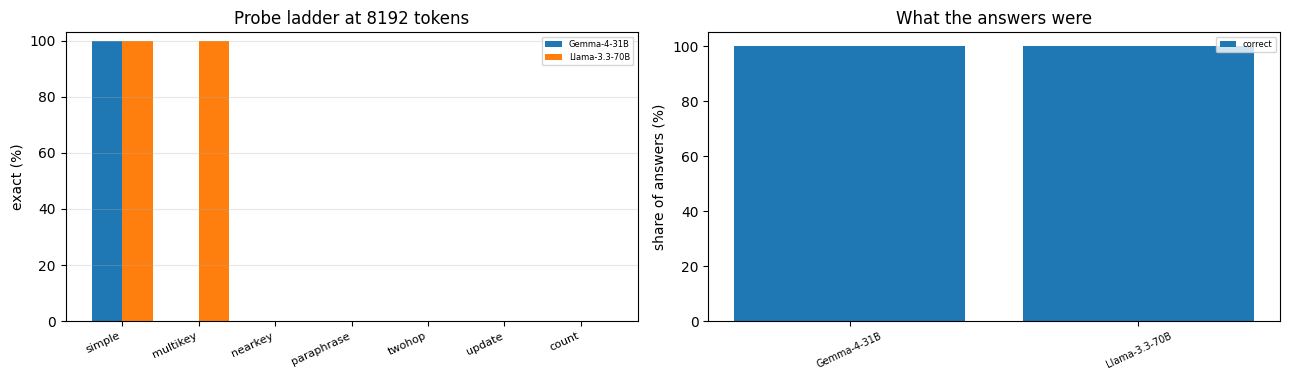

In [6]:
import matplotlib.pyplot as plt

L = LENGTHS[0]
labels = [m for m in MODELS if any(key[0] == m and key[1] == L for key in cells)]
if labels:
    fig, ax = plt.subplots(1, 2, figsize=(13, 3.9))
    width = 0.8 / len(labels)
    for i, m in enumerate(labels):
        vals = [100 * sum(r["ok"] for r in cells[(m, L, p)]) / len(cells[(m, L, p)])
                if cells.get((m, L, p)) else 0 for p in PROBES]
        ax[0].bar([x + i * width for x in range(len(PROBES))], vals, width, label=m)
    ax[0].set_xticks([x + 0.4 - width / 2 for x in range(len(PROBES))])
    ax[0].set_xticklabels(PROBES, rotation=25, ha="right", fontsize=8)
    ax[0].set_ylabel("exact (%)"); ax[0].set_ylim(0, 103)
    ax[0].set_title(f"Probe ladder at {L} tokens"); ax[0].grid(alpha=0.3, axis="y")
    ax[0].legend(fontsize=6)

    kinds = ["correct", "wrong_fact", "stale_value", "invented", "no_code", "miscount", "no_number",
             "cut_off"]
    bottom = [0.0] * len(labels)
    for kind in kinds:
        vals = []
        for m in labels:
            rs = [r for r in rows if r["label"] == m and r["length"] == L]
            vals.append(100 * sum(r["verdict"] == kind for r in rs) / max(len(rs), 1))
        if any(vals):
            ax[1].bar(labels, vals, bottom=bottom, label=kind)
            bottom = [b + v for b, v in zip(bottom, vals)]
    ax[1].set_ylabel("share of answers (%)"); ax[1].set_title("What the answers were")
    ax[1].tick_params(axis="x", rotation=25, labelsize=7); ax[1].legend(fontsize=6)
    plt.tight_layout(); plt.savefig(OUT_DIR / "hosted_probes.png", dpi=160); plt.show()
else:
    print("nothing to plot yet")

## Reading the output

- **This checks whether the pattern holds at scale.** At the default of five
  prompts per cell the intervals are wide. The useful question is whether the
  ladder's shape (which probes fail, and how) survives at 70B, not the exact
  level. Raise `PROMPTS` when a provider's allowance permits.
- **Not the same scoring as the local notebook.** Local models are base
  checkpoints scored by teacher forcing; these are instruction-tuned models that
  generate an answer. Compare the order of probes, not absolute numbers.
- **Thinking changes the task.** The two tables are not comparable. A model
  that thinks can list the candidate codes in its own output and pick one, which
  is search, not one-pass retrieval. The hybrids fall in that table because their
  providers do not allow thinking to be switched off, so a hybrid-against-dense
  comparison in this notebook is confounded by thinking. Say so if it is reported.
- **`cut_off`** means the token budget ran out before an answer. Those replies are
  left out of the accuracy tables and counted separately.
- **`count` stays separate.** A model can find any single fact and still fail to
  aggregate over all of them. Averaging it with retrieval would hide that.
- **Lengths are measured with Qwen's tokenizer.** The provider's own count, printed
  at the end, can be 10 to 30% higher for other tokenizers.
- **Check the token counts.** If a provider reports far fewer prompt tokens than
  were sent, it truncated the context and those rows are not long-context results.
- **No sink numbers here, by design.** An API returns text, not attention.
  Sink mass and the position-0 intervention come from the local notebook.

`hosted_probe_results.jsonl` (on Drive) holds every call, reply and verdict.
Copy it into `notebooks/` with the executed notebook for evaluation.